# <span style="color:rgb(160,0,86)">Testverfahren mit Resampling</span>

***

## <span style="color:rgb(160,0,86)">Lernziele</span>

- Sie können eine **Varianzanalyse** durchführen.  
- Sie verstehen was ein **Q-Q-Diagramm** darstellt.
- Sie können einen **Chi-Quadrat-Test** durchführen.  

***

### <span style="color:rgb(160,0,86)">Was ist eine Varianzanalyse?</span>

Nehmen wir an, dass wir anstelle eines A/B-Tests <center>**einen Vergleich zwischen mehreren Gruppen A-B-C-D**</center>

mit jeweils numerischen Daten haben. Das statistische Verfahren, mit dem auf einen statistisch signifikanten **Unterschied zwischen den Gruppen** getestet wird, heisst **Varianzanalyse** oder **ANOVA**.

#### <span style="color:rgb(160,0,86)">Beispiel: Verweildauer auf vier Webseiten</span>

Wir betrachen die **Verweildauer (stickiness)** auf vier Webseiten. Die vier Seiten werden nach dem Zufallsprinzip ausgetauscht, so dass jeder Webbesucher eine zufällige Seite erhält. Insgesamt gibt es ***fünf Besucher für jede Seite***. 

- Beachten Sie, dass wir bei so einem Webtest die ***klassische Zufallsstichprobe***, bei der jeder Besucher nach dem Zufallsprinzip aus einer grossen Grundgesamtheit ausgewählt wird, **nicht vollständig umsetzen können**. <br> Wir müssen die Besucher so nehmen, wie sie kommen. Die Besucher können sich ***systematisch unterscheiden***, abhängig von der Tageszeit, der Wochenzeit, der Jahreszeit, den Internet-Bedingungen, dem verwendeten Gerät und so weiter. 

- Diese Faktoren sollten bei der Überprüfung der Versuchsergebnisse als **potenzielle Verzerrungen** berücksichtigt werden.

<span style="color:rgb(160,0,86)">**Nun haben wir ein Problem.**</span> 

Als wir **nur zwei Gruppen** verglichen haben, war es eine einfache Angelegenheit:
- Wir haben lediglich die Differenz zwischen den Mittelwerten der einzelnen Gruppen betrachtet.

Bei **vier Mittelwerten** gibt es ***sechs mögliche Vergleiche*** zwischen den Gruppen: $$\begin{array}{ll}
\textbf{1)} & \texttt{Seite 1 im Vergleich zu Seite 2} \\ 
\textbf{2)} & \texttt{Seite 1 im Vergleich zu Seite 3} \\ 
\textbf{3)} & \texttt{Seite 1 im Vergleich zu Seite 4} \\ 
\textbf{4)} & \texttt{Seite 2 im Vergleich zu Seite 3} \\ 
\textbf{5)} & \texttt{Seite 2 im Vergleich zu Seite 4} \\ 
\textbf{6)} & \texttt{Seite 3 im Vergleich zu Seite 4} 
\end{array}$$

Wenn wir **allgemein** $\,\pmb{n}\,$ Seiten Vergleichen, gibt es $$\pmb{\binom{n}{2}} = \frac{n!}{2!\cdot (n-2)!} = \pmb{\frac{n\cdot(n-1)}{2}} \;\,\textbf{ m\"ogliche Vergleiche.} $$ 

<span style="color:rgb(160,0,86)">***Je mehr solcher paarweisen Vergleiche wir anstellen, desto grösser ist die Gefahr, dass wir uns vom Zufall täuschen lassen.***</span> 

Anstatt sich über all die verschiedenen Vergleiche zwischen einzelnen Seiten Gedanken zu machen, können wir **einen einzigen Gesamttest** durchführen, der sich mit der Frage befasst: 
- Könnten die beobachteten Unterschiede zwischen den vier Seiten ***allein durch Zufall*** entstanden sein, wenn alle Seiten ***tatsächlich das gleiche Nutzerverhalten*** aufweisen?</span>

Das Verfahren, mit dem dies getestet wird, ist die **Varianzanalyse**. Die Grundlage dafür ist das folgende **Resampling-Verfahren**, hier spezifiziert für den A-B-C-D-Test der vier Webseiten:

<span style="color:rgb(160,0,86)"> ***Pseudocode:*** </span>

<span style="font-family: monospace"><strong>Eingabe:</strong> Daten aus mehreren Gruppen A, B, C, D, ... <br>
<strong>Schritt 1:</strong> Berechne die beobachtete Varianz $\sigma^2_{\text{beobachtet}}$ der Gruppenwerte <br> <strong>Schritt 2:</strong> Wiederhole viele Male: <br>
$\quad\quad$ <strong>a)</strong> Lege die Werte aus allen Gruppen zusammen.<br>
$\quad\quad$ <strong>b)</strong> Teile sie zufällig in Gruppen gleicher Grösse wie A, B, C, D, ...<br>
$\quad\quad$ <strong>c)</strong> Berechne erneut die Varianz $\sigma^2_{\text{resample}}$ der Gruppenwerte und speichere sie<br>
<strong>Schritt 3:</strong> Bestimme die relative Häufigkeit, wie oft die Varianz $\sigma^2_{\text{resample}}$ grösser ist als die beobachtete Varianz $\sigma^2_{\text{beobachtet}}$. <br> <strong>Ausgabe:</strong> Der p-Wert, also die bei Schritt 3 berechnete relative Häufigkeit. <br></span>

Der **Ablauf des Testentscheids** unterscheidet sich nicht von den bisher behandelten Verfahren.

### <span style="color:rgb(160,0,86)">Aufgabe 1</span>

Laden Sie die Daten der Stichprobe in der Datei *four_sessions.csv* im Ordner Daten. 
- Zeichnen Sie für die Verweildauer vier Boxplots, je für die Seite A, B, C und D.
- Wie lautet die **Nullhypothese** und die entsprechende **Alternativhypothese**?
- Bestimmen Sie die **beobachtete Varianz**.
- Bestimmen Sie mit dem Resampling-Verfahren für die Varianzanalyse eine Menge von 1000 permutieren Varianzen und stellen Sie die Verteilung dieser Varianzen in einem Dichtediagramm dar. Zeichnen Sie in das gleiche Diagramm auch die beobachtete Varianz ein.
- Bestimmen Sie den $\pmb{p}\textbf{-Wert}$ und machen Sie auf dem **Signifikanzniveau von 5%** einen Testentscheid.

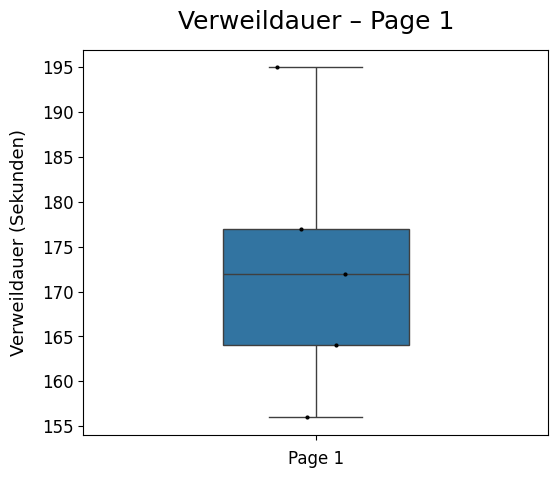

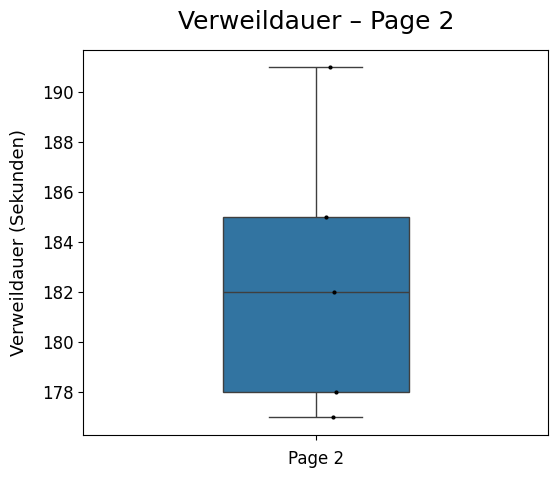

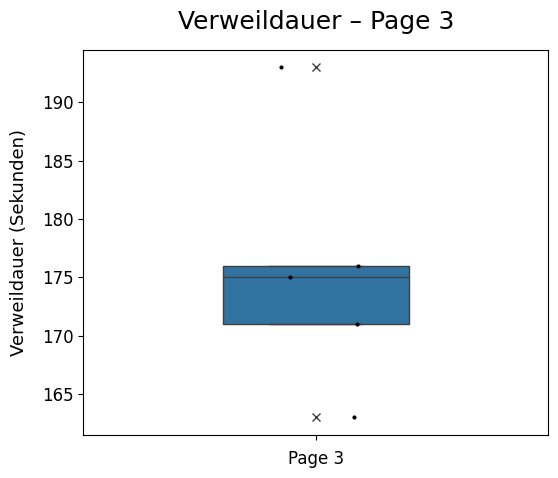

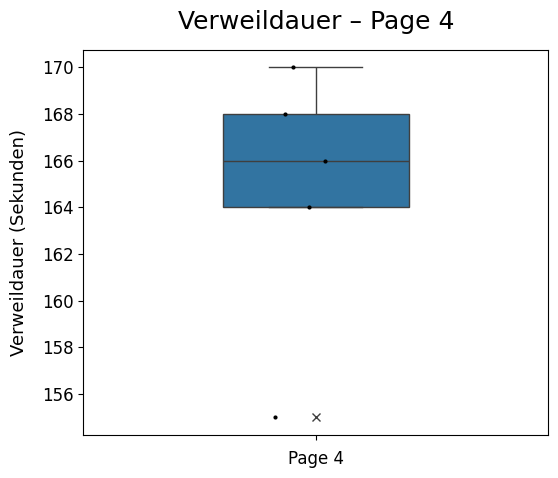

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sessions = pd.read_csv("/Users/muellefa/repos/ASTAT/SW08/Daten/four_sessions.csv")

# Einzigartige Seiten
pages = sessions["Page"].unique()

# Boxplots (nach deiner Referenz)
# Für jede Seite ein eigenes Diagramm zeichnen
for page in pages:
    subset = sessions[sessions["Page"] == page]
    
    fig = plt.figure(figsize=(6,5))
    axi = fig.add_subplot(1,1,1)
    sns.boxplot(y="Time", data=subset, width=0.4, flierprops={"marker":"x"}, ax=axi)
    sns.stripplot(y="Time", data=subset, color="black", size=3, ax=axi)
    axi.set_title(f"Verweildauer – {page}", fontsize=18, pad=15)
    axi.set_xlabel(page, fontsize=12)
    axi.set_ylabel("Verweildauer (Sekunden)", fontsize=13, labelpad=10)
    axi.tick_params(axis="y", labelsize=12)
    plt.show()
    

    
    
    
    plt.show()



Wir machen nun einen Hypothesen-Test:
- **Nullhypothese:** Die mittlere Verweildauer ist bei allen Seiten gleich.
- **Alternativhypothese:** Die mittlere Verweilduaer ist nicht gleich.


In [21]:
import numpy as np

# Gesamtmittel
overall_mean = sessions["Time"].mean()

# Gruppenmittel und -grössen
group_means = sessions.groupby("Page")["Time"].mean()
group_sizes = sessions["Page"].value_counts()

# Sum of Squares zwischen den Gruppen
ss_between = sum(group_sizes[page] * (group_means[page] - overall_mean)**2
                 for page in group_means.index)

df_between = sessions["Page"].nunique() - 1  # k-1
var_beobachtet = ss_between / df_between

print("Beobachtete Varianz:", var_beobachtet)

Beobachtete Varianz: 277.13333333333327


p-Value in %: 6.5


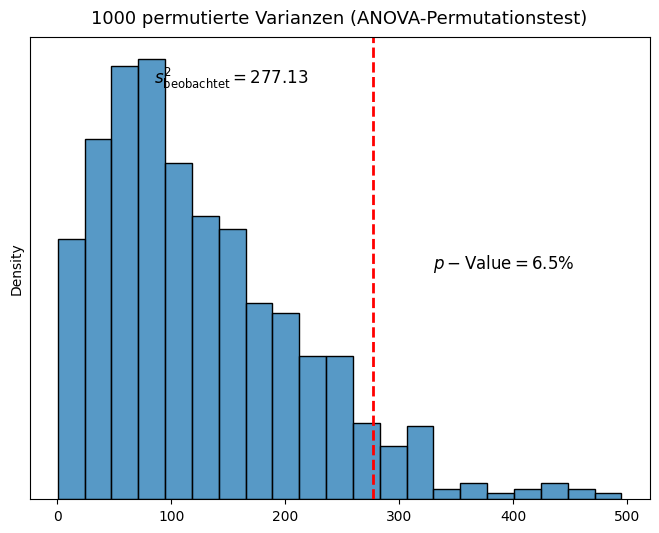

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Alle Time-Werte
sample = sessions["Time"].values

# Gruppengrössen pro Seite merken
group_sizes_dict = sessions["Page"].value_counts().to_dict()
pages = sessions["Page"].unique()

var_permutiert = []

# Permutationstest
for _ in range(1000):
    # zufällige Permutation der Zeiten
    sample_perm = np.random.permutation(sample)
    
    start = 0
    ss_between_perm = 0
    overall_mean_perm = sample_perm.mean()
    
    # wieder in 4 Gruppen (Pages) aufteilen
    for p in pages:
        n = group_sizes_dict[p]
        gruppe = sample_perm[start:start+n]
        start += n
        
        ss_between_perm += n * (gruppe.mean() - overall_mean_perm)**2
    
    var_permutiert.append(ss_between_perm / df_between)

# p-Wert (einseitig, Varianz >= beobachtet)
p_value = 100 * (np.array(var_permutiert) >= var_beobachtet).mean()
print("p-Value in %:", p_value)

fig = plt.figure(figsize=(8,6))
axi = fig.add_subplot(1,1,1)

# Dichtediagramm (Histogramm) der permutierten Varianzen
sns.histplot(var_permutiert, stat="density", ax=axi)

# Vertikale Linie bei der beobachteten Varianz
axi.axvline(var_beobachtet, color="red", lw=2, linestyle="dashed")

# Texte in der Grafik
axi.text(0.2, 0.9,
         r"$s^2_{\mathrm{beobachtet}}=$" + "{v:1.2f}".format(v=var_beobachtet),
         fontsize=12, transform=plt.gca().transAxes)

axi.text(0.65, 0.5,
         r"$p-$Value$ = $" + "{p:1.1f}%".format(p=p_value),
         fontsize=12, transform=plt.gca().transAxes)

axi.set_title("1000 permutierte Varianzen (ANOVA-Permutationstest)",
              fontsize=13, pad=10)
axi.set_xlabel("")
axi.set_yticks([])

plt.show()



### <span style="color:rgb(160,0,86)">Wie werden Verteilungen verglichen?</span>

Eine ***graphische Methode*** ist das sogenannte 
- **Q-Q-Diagramm** (Quantil-Quantil-Diagramm) zum Vergleich zweier Verteilungen. 

In einem Q-Q-Diagramm werden die **Quantile der zwei Verteilungen** gegeneinander aufgetragen. 
- Jeder Punkt $\,\pmb{(x,y)}\,$ im Diagramm entspricht einem Quantil: Die $\,\pmb{x}$-Koordinate zeigt das Quantil in der ersten Verteilung, die 
$\,\pmb{y}$-Koordinate das gleiche Quantil in der zweiten Verteilung.

Wenn die beiden zu vergleichenden **Verteilungen ähnlich** sind, liegen die Punkte im Q-Q-Diagramm **annähernd auf einer Linie**.

<center>
<img src="Bilder/QQPlot.png" width="50%" />
</center>

Wir können das Prüfen, in dem wir zufällige Werte aus der Normalverteilung $\,\pmb{\mathsf{Norm}(\mu=2,\sigma=1.5)}\,$ wählen und diese Stichprobe mit den theoretischen Quantilen der Normalverteilung vergleichen.

Wir ziehen **100 zufällige Zahlen unter dieser Verteilung**:

In [2]:
from scipy.stats import norm, t

X = norm(loc=2,scale=1.5)
stichprobe = X.rvs(100)

Nun bestimmen wir **100 Quantile der Normalverteilung** und der **t-Verteilung**:

In [3]:
import numpy as np

# 100 gleichmässig verteile Wahrscheinlichkeiten im Intervall (0,1)
P = np.linspace(0,1,102)[1:101]

# Die 100 entsprechenden theoretische Quantile 
q_normal = X.ppf(P)
q_t = t.ppf(P, df=4, loc=2, scale=1.5)

Im **Q-Q-Diagramm** zeichnen wir die Verteilung der Stichprobe auf der $\,\pmb{y}$-Achse und die theoretische Verteilung auf der $\,\pmb{x}$-Achse:

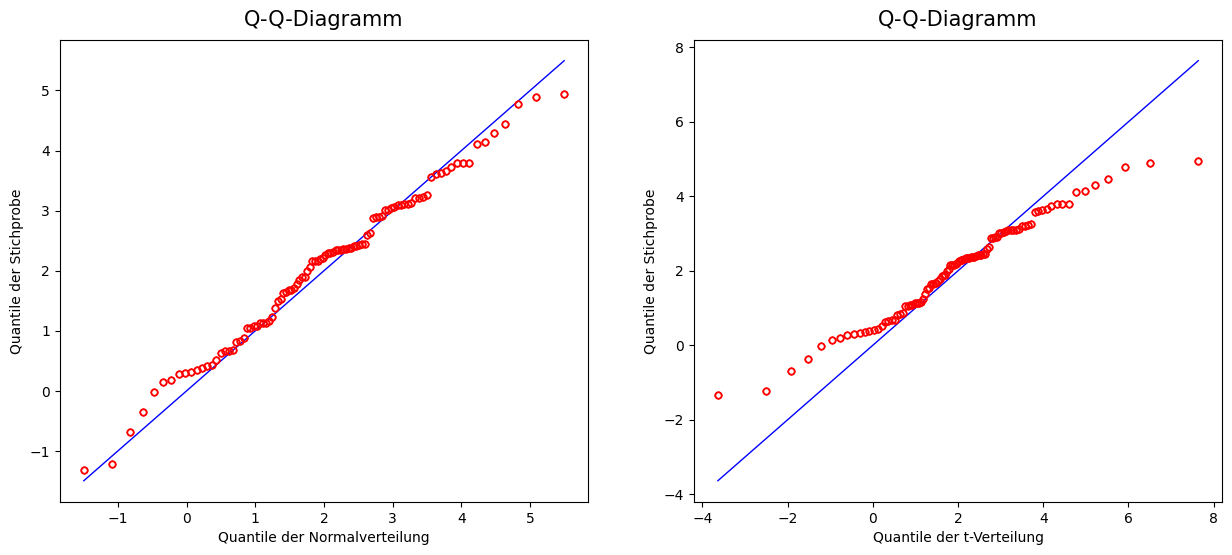

In [4]:
import matplotlib.pyplot as plt

# Koordinaten der kleinsten und grössen Werte (für die blaue Gerade):
x_min_normal = min(stichprobe.min(),q_normal.min()) 
x_max_normal = max(stichprobe.max(),q_normal.max())
x_min_t = min(stichprobe.min(),q_t.min()) 
x_max_t = max(stichprobe.max(),q_t.max())

# QQ-Plot:
fig = plt.figure(figsize=(15,6))

ax1 = fig.add_subplot(1,2,1)
ax1.plot([q_normal.min(), q_normal.max()], [q_normal.min(), q_normal.max()],
         color="blue",lw=1)
ax1.plot(q_normal,np.sort(stichprobe),
         linestyle="None",marker="$\u25EF$",color="red",markersize=5)
ax1.set_title("Q-Q-Diagramm",fontsize=15,pad=10)
ax1.set_xlabel("Quantile der Normalverteilung")
ax1.set_ylabel("Quantile der Stichprobe")

ax2 = fig.add_subplot(1,2,2)
ax2.plot([q_t.min(), q_t.max()], [q_t.min(), q_t.max()],
         color="blue",lw=1)
ax2.plot(q_t,np.sort(stichprobe),
         linestyle="None",marker="$\u25EF$",color="red",markersize=5)
ax2.set_title("Q-Q-Diagramm",fontsize=15,pad=10)
ax2.set_xlabel("Quantile der t-Verteilung")
ax2.set_ylabel("Quantile der Stichprobe")

# Figur zeigen
plt.show()

Die Form der Abweichung zeigt die Abweichung von der theoretischen Verteilung. 

- **Die Winkelhalbierende ist der Bezugspunkt:** Sie stellt die perfekte Übereinstimmung dar. Punkte liegen nur dann auf der Gerraden, wenn jedes Quantil der Stichprobe exakt dem theoretischen Quantil entspricht.
- **Punkte oberhalb der Linie:** Die beobachteten Werte sind grösser als erwartet.
- **Punkte unterhalb der Linie:** Die beobachteten Werte sind kleiner als erwartet.

<span style="color:rgb(160,0,86)"> ***Merksatz:*** </span> Die Gerade wird immer als **Referenzlinie im QQ-Plot** gezeichnet.




### <span style="color:rgb(160,0,86)">Aufgabe 2</span>

- Laden Sie die Daten der Stichprobe in der Datei *Palette.sav* und *loans_income.csv* im Ordner Daten.
- Prüfen Sie mit einem **Q-Q-Diagramm** für alle Merkmale in diesen Daten, ob sie normalverteilt sind.   

In [27]:
import pandas as pd

# SPSS-Datei laden (.sav)
palette = pd.read_spss("/Users/muellefa/repos/ASTAT/SW08/Daten/Palette.sav")

# CSV-Datei laden
loans = pd.read_csv("/Users/muellefa/repos/ASTAT/SW08/Daten/loans_income.csv")

# Kontrolle
print("Palette:")
print(palette.head(), "\n")

print("Loans:")
print(loans.head())

Palette:
    Nummer  Breite  Höhe  Gewicht
0  10001.0    44.7  58.5     66.5
1  10002.0    44.0  60.1     65.5
2  10003.0    44.4  57.2     63.0
3  10004.0    43.3  59.2     64.5
4  10005.0    45.3  57.6     65.5 

Loans:
        x
0   67000
1   52000
2  100000
3   78762
4   37041


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

def qq_plot(stichprobe, titel):
    stichprobe = np.sort(stichprobe)
    n = len(stichprobe)

    # Plotting-Positionen (Wahrscheinlichkeiten)
    p = (np.arange(1, n+1) - 0.5) / n

    # Parameter aus der Stichprobe (für "passende" Verteilung)
    mu = stichprobe.mean()
    sigma = stichprobe.std(ddof=1)

    # Theoretische Quantile
    q_normal = norm.ppf(p, loc=mu, scale=sigma)
    q_t      = t.ppf(p, df=n-1, loc=mu, scale=sigma)

    # Koordinaten min/max für die Diagonalen
    x_min_normal = min(stichprobe.min(), q_normal.min())
    x_max_normal = max(stichprobe.max(), q_normal.max())
    x_min_t = min(stichprobe.min(), q_t.min())
    x_max_t = max(stichprobe.max(), q_t.max())

    # QQ-Plot:
    fig = plt.figure(figsize=(15,6))

    ax1 = fig.add_subplot(1,2,1)
    ax1.plot([x_min_normal, x_max_normal],
             [x_min_normal, x_max_normal],
             color="blue", lw=1)
    ax1.plot(q_normal, stichprobe,
             linestyle="None", marker="$\u25EF$", color="red", markersize=5)
    ax1.set_title(f"Q–Q-Diagramm (Normal) – {titel}", fontsize=15, pad=10)
    ax1.set_xlabel("Quantile der Normalverteilung")
    ax1.set_ylabel("Quantile der Stichprobe")

    ax2 = fig.add_subplot(1,2,2)
    ax2.plot([x_min_t, x_max_t],
             [x_min_t, x_max_t],
             color="blue", lw=1)
    ax2.plot(q_t, stichprobe,
             linestyle="None", marker="$\u25EF$", color="red", markersize=5)
    ax2.set_title(f"Q–Q-Diagramm (t-Verteilung) – {titel}", fontsize=15, pad=10)
    ax2.set_xlabel("Quantile der t-Verteilung")
    ax2.set_ylabel("Quantile der Stichprobe")

    plt.show()


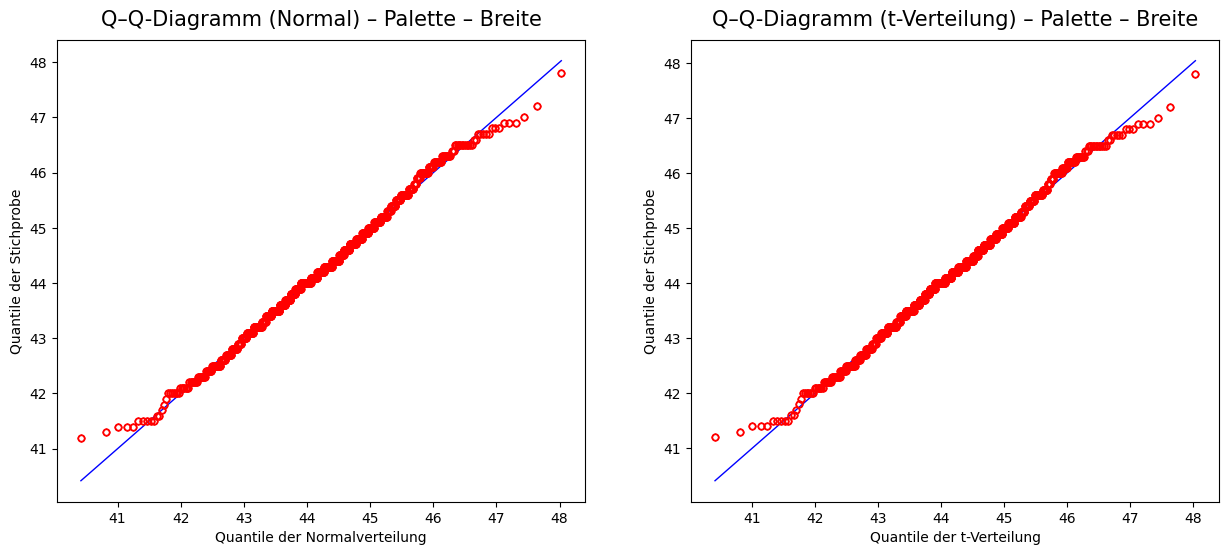

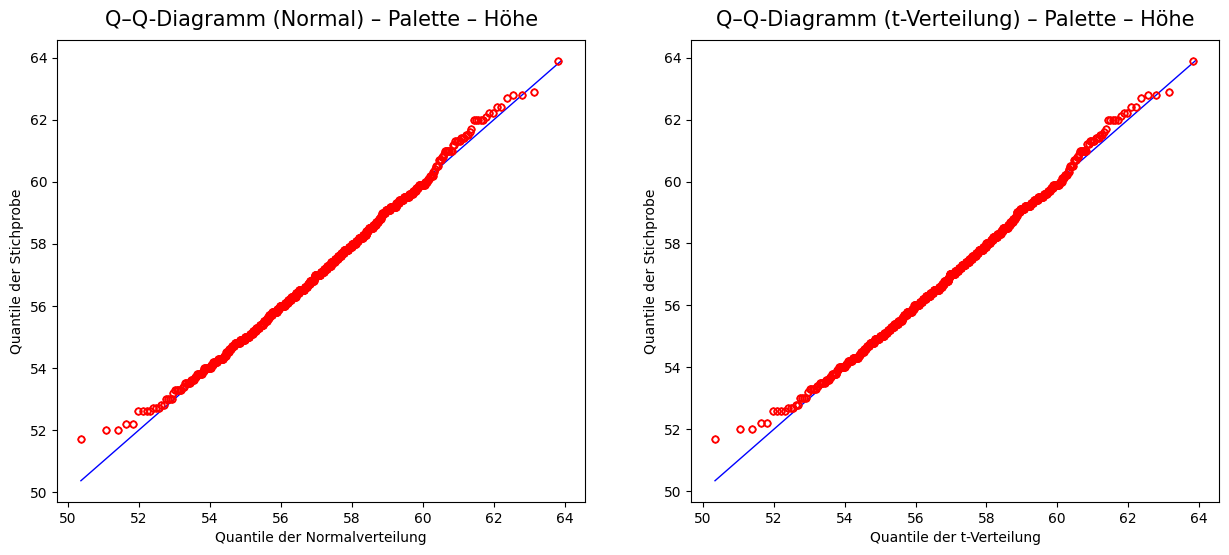

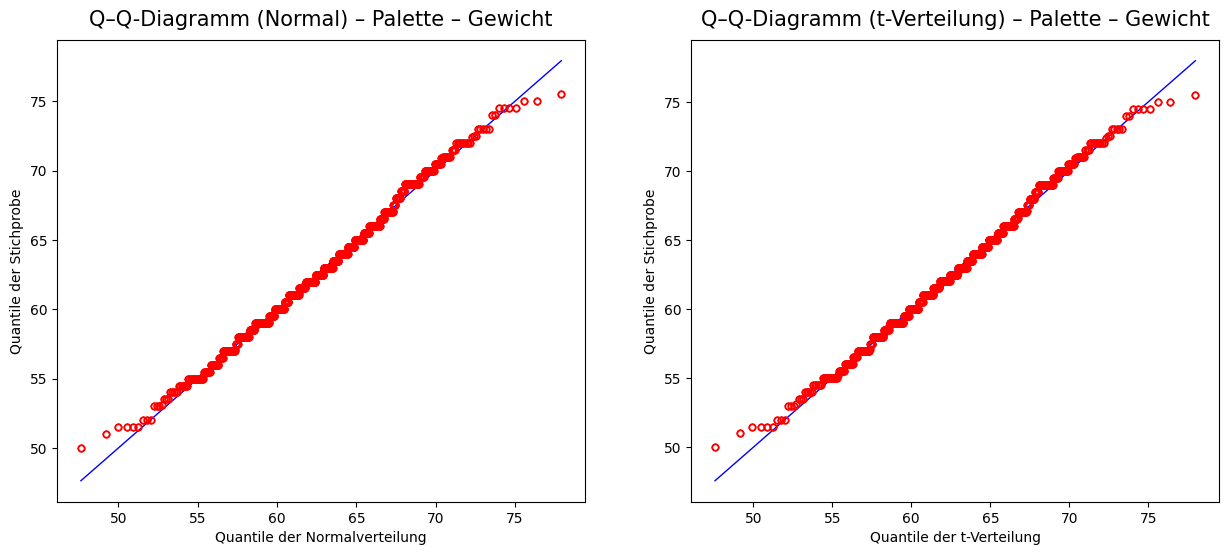

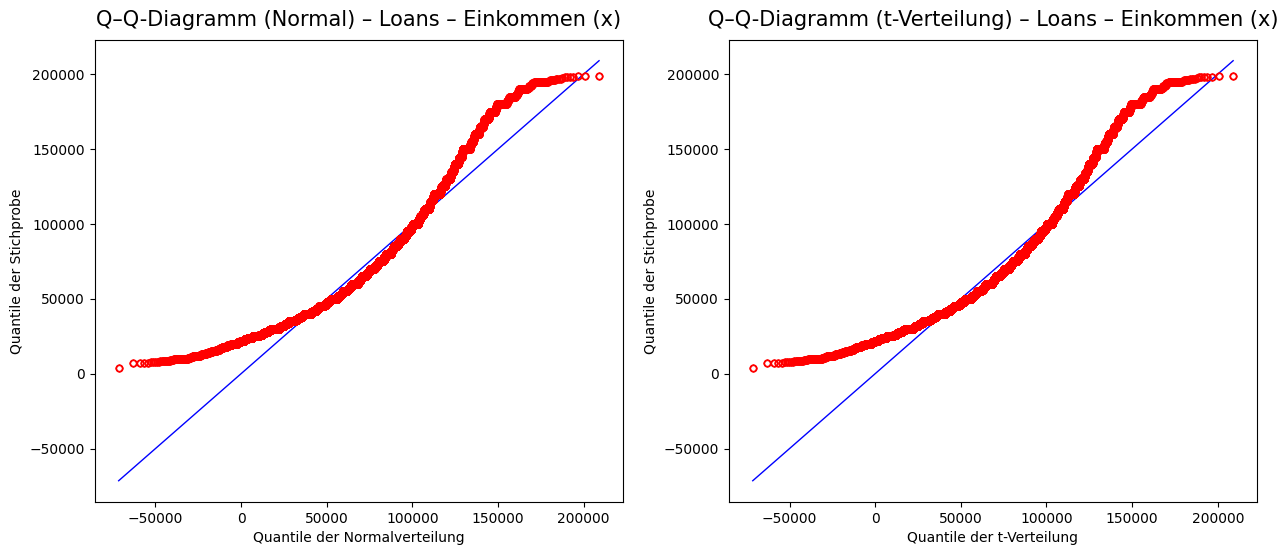

In [29]:
# Breite
qq_plot(palette["Breite"].dropna().values, "Palette – Breite")

# Höhe
qq_plot(palette["Höhe"].dropna().values, "Palette – Höhe")

# Gewicht
qq_plot(palette["Gewicht"].dropna().values, "Palette – Gewicht")

# Loans
qq_plot(loans["x"].dropna().values, "Loans – Einkommen (x)")

### <span style="color:rgb(160,0,86)">Was ist der Chi-Quadrat-Test?</span>

Web-Tests gehen oft über A/B-Tests hinaus und testen ***mehrere Behandlungs-Varianten*** auf einmal. Der **Chi-Quadrat-Test** wird bei Daten verwendet, um zu prüfen, wie gut sie einer **erwarteten Verteilung** entsprechen.

Der Chi-Quadrat-Test wurde ursprünglich von **Karl Pearson** im Jahr 1900 entwickelt. Der Begriff ***chi*** stammt von dem griechischen Buchstaben $\pmb{\chi}$, den Pearson in dem Artikel verwendete.

#### <span style="color:rgb(160,0,86)">Ein Resampling-Ansatz für den Chi-Quadrat-Test</span>

Angenommen, wir testen drei verschiedene Schlagzeilen A, B und C und führen sie jeweils mit 1000 Besuchern durch. Die Ergebnisse sind in folgender Tabelle dargestellt.

$$\begin{array}{c|ccc}
& \textbf{Schlagzeile A} & \textbf{Schlagzeile B} & \textbf{Schlagzeile C} \\ \hline
\textbf{Klick} & 14 & 8 & 12\\
\textbf{kein Klick} & 986 & 992 & 988\\ 
\end{array}$$
- Die **Schlagzeilen scheinen sich deutlich zu unterscheiden.**  Schlagzeile A hat eine fast doppelt so hohe Klickrate wie B.
- Die **tatsächlichen Zahlen sind jedoch gering**.

Mit einem ***Resampling-Verfahren*** kann getestet werden, ob sich die Klickraten in einem grösseren Ausmass unterscheiden, als es der Zufall verursachen könnte. 

Für diesen Test benötigen wir die ***erwartete Verteilung der Klicks***, dass alle drei Schlagzeilen die gleiche Klickrate haben, also eine Klickrate von $$\frac{14+8+12}{1000+1000+1000}=\frac{34}{3000}=0.011\overline{3}$$ für alle drei Schlagzeilen.

Aus dieser erwarteten Klickrate können wir die ***erwarteten Häufigkeiten*** bestimmen, wenn es keinen Unterschied zwischen den Schlagzeilen gibt:

$$\begin{array}{c|ccc}
& \textbf{Schlagzeile A} & \textbf{Schlagzeile B} & \textbf{Schlagzeile C} \\ \hline
\textbf{Klick} & 11.\overline{3} & 11.\overline{3} & 11.\overline{3}\\
\textbf{kein Klick} & 998.\overline{6} & 998.\overline{6} & 998.\overline{6}\\ 
\end{array}$$
Das sogenannte **quadratische Pearson-Residuum** $$R^2=\frac{(\text{beobachtete Häufigkeit}-\text{erwartete Häufigkeit})^2}{\text{erwartete Häufigkeit}}$$ misst das Aussmass, wie stark sich die **beobachteten Häufigkeiten** und die **erwarteten Häufigkeiten** unterscheiden. 

Die **Chi-Quadrat-Metrik** $\pmb{\chi^2}$ ist definiert als die **Summe der quadrierten Pearson-Residuen**:
$$\pmb{\chi^2} = 
\pmb{R}_{\text{\small A,Klick}}^2 + \pmb{R}_{\text{\small A,kein Klick}}^2 + \pmb{R}_{\text{\small B,Klick}}^2 + \pmb{R}_{\text{\small B,kein Klick}}^2 + \pmb{R}_{\text{\small C,Klick}}^2 + \pmb{R}_{\text{\small C,kein Klick}}^2$$
wobei über **alle Zeilen** und **Spalten der Tabelle** addiert wird. 

Ob die Chi-Quadrat-Metrik für dieses Beispiel grösser ist als bei einem Zufallsmodell,  können wir mit dem folgenden **Resampling-Algorithmus** testen:


<span style="color:rgb(160,0,86)"> ***Pseudocode:*** </span>

<span style="font-family: monospace"><strong>Eingabe:</strong> Daten aus Gruppen A, B, C, D, ..., erwartete Verteilung eines Merkmals<br>
<strong>Schritt 1:</strong> Berechne den beobachteten Chi-Quadrat-Wert $\chi^2_{\text{beobachtet}}$ <br> <strong>Schritt 2:</strong> Wiederhole viele Male: <br>
$\quad\quad$ <strong>a)</strong> Lege die Werte aus allen Gruppen zusammen.<br>
$\quad\quad$ <strong>b)</strong> Teile sie zufällig in Gruppen gleicher Grösse wie A, B, C, D, ...<br>
$\quad\quad$ <strong>c)</strong> Berechne erneut den Chi-Quadrat-Wert $\chi^2_{\text{resample}}$ und speichere ihn<br>
<strong>Schritt 3:</strong> Bestimme die relative Häufigkeit, wie oft der Chi-Quadrat-Wert $\chi^2_{\text{resample}}$ grösser ist als der beobachtete Chi-Quadrat-Wert $\chi^2_{\text{beobachtet}}$. <br> <strong>Ausgabe:</strong> Der p-Wert, also die bei Schritt 3 berechnete relative Häufigkeit. <br></span>

Der **Ablauf des Testentscheids** unterscheidet sich nicht von den bisher behandelten Verfahren.

### <span style="color:rgb(160,0,86)">Aufgabe 3</span>

Laden Sie die Daten der Stichprobe in der Datei *click_rates.csv* im Ordner Daten. 
- Wie lautet die **Nullhypothese** und die entsprechende **Alternativhypothese**?
- Bestimmen Sie mit dem Resampling-Verfahren für den **Chi-Quadrat-Test** eine Menge von 1000 permutieren Summen der quadrierten Pearson-Residuen und stellen Sie die Verteilung dieser Werte in einem Dichtediagramm dar. Zeichnen Sie in das gleiche Diagramm auch die beobachtete Summe der quadrierten Pearson-Residuen ein.
- Bestimmen Sie den $\pmb{p}\textbf{-Wert}$ und machen Sie auf dem **Signifikanzniveau von 5%** einen Testentscheid.

In [6]:
# To do!

### <span style="color:rgb(160,0,86)">Aufgabe 4</span>
Ein interessantes Beispiel ist die Forscherin **Thereza Imanishi-Kari** von der Tufts University, die 1991 beschuldigt wurde, in ihrer Forschung Daten gefälscht zu haben. Der Kongressabgeordnete John Dingell schaltete sich ein, und der Fall führte schliesslich zum Rücktritt ihres Kollegen David Baltimore von der Präsidentschaft der Rockefeller University.

Imanishi-Kari wurde nach einem langwierigen Verfahren entlastet. Ein Teil des Falles beruhte jedoch auf statistischen Beweisen für die erwartete Verteilung der Ziffern in ihren Labordaten, bei denen jede Beobachtung viele Ziffern aufwies. Die Ermittler konzentrierten sich auf die *inneren Ziffern*, von denen man annehmen kann, dass sie einer gleichmässigen Zufallsverteilung folgen. Das heisst, sie treten nach dem Zufallsprinzip auf, wobei jede Ziffer mit gleicher Wahrscheinlichkeit vorkommt (die führende Ziffer könnte überwiegend einen Wert haben, und die Endziffern könnten durch Rundung beeinflusst werden). In der Datei *imanishi_data.csv* im Ordner Daten sind die Häufigkeiten der inneren Ziffern aus den tatsächlichen Daten des Falles aufgeführt.

Laden Sie die Daten der Stichprobe in der Datei *imanishi_data.csv* im Ordner Daten.
- Zeichnen Sie ein Dichtediagramm für die Häufigkeiten der *inneren Ziffern*.
- Wie lautet die **Nullhypothese** und die entsprechende **Alternativhypothese**?
- Bestimmen Sie mit dem Resampling-Verfahren für den **Chi-Quadrat-Test** eine Menge von 1000 permutieren Summen der quadrierten Pearson-Residuen und stellen Sie die Verteilung dieser Werte in einem Dichtediagramm dar. Zeichnen Sie in das gleiche Diagramm auch die beobachtete Summe der quadrierten Pearson-Residuen ein.
- Bestimmen Sie den $\pmb{p}\textbf{-Wert}$ und machen Sie auf dem **Signifikanzniveau von 5%** einen Testentscheid.

In [7]:
# To do!

### <span style="color:rgb(160,0,86)">Was sind mehrarmige Banditen?</span>
To do for Berger:
- Epsilon-Greedy-Algorithmus
- Thompson Sampling
- Beispieldaten suchen

![HSLU](Bilder/LogoHSLU.png)